## Setup: `notebooks/data/` must exist first

This notebook is self-contained: it only reads from `notebooks/data/` and `notebooks/utils/`, never
from the rest of the `genomics` package or any external dataset mount. If `notebooks/data/` doesn't
exist yet (or you want to refresh it -- e.g. to add genes or widen the individuals covered), run
**[`prepare_data.ipynb`](./prepare_data.ipynb)** first. That notebook builds `notebooks/data/` from
the raw 1000 Genomes sources (pedigree/population CSV, GENCODE GTF, reference FASTA, per-chromosome
phased VCFs) -- it's the only place in this workflow that needs `bcftools`/`samtools` and access to
those external files.

In [1]:
import os
import sys
import json
from pathlib import Path
import requests

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# This notebook is self-contained: it only reads from notebooks/data/ (bundled, small
# reference/variant slices -- see notebooks/utils/prepare_data.py for how that was built)
# and notebooks/utils/ (plain Python helpers), never from the rest of the `genomics`
# package or the external dataset mount.
REPO_ROOT = Path("/home/breno/I2CA/genomics")
NOTEBOOK_DIR = REPO_ROOT / "notebooks"
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))
os.chdir(NOTEBOOK_DIR)

from utils import data as data_utils
from utils import consensus as consensus_utils
from utils import realignment
from utils import predictions as predictions_utils

# Importing the alphagenome client module itself needs no API key -- only `dna_client.create()`
# (Section "AlphaGenome client" below) does. Imported here so constants like
# `dna_client.SEQUENCE_LENGTH_500KB` are available to Section 1 without requiring the key yet.
from alphagenome.data import genome
from alphagenome.models import dna_client

experiment = data_utils.load_experiment()
GENES = experiment["genes"]
ONTOLOGY_TERMS = experiment["ontology_terms"]
CLASS_MAP = experiment["class_map"]
WINDOW_CENTER_SIZE = experiment["window_center_size"]

gene_rows = data_utils.load_genes()
individuals = data_utils.load_individuals()
samples_by_class = data_utils.samples_by_class(individuals, CLASS_MAP)

print(f"Genes ({len(GENES)})       : {GENES}")
print(f"Ontology terms    : {ONTOLOGY_TERMS}")
print(f"window_center_size: {WINDOW_CENTER_SIZE}")
print(f"class_map          : {CLASS_MAP}")
print(f"individuals loaded : {len(individuals)} ({', '.join(f'{k}: {len(v)}' for k, v in samples_by_class.items())})")

from dotenv import load_dotenv

# Picks up ALPHAGENOME_API_KEY from either the shell environment or ~/.env (this repo's
# convention for storing API keys outside of chat/context -- see the `credentials` skill).
load_dotenv(Path.home() / ".env")
API_KEY = os.environ.get("ALPHAGENOME_API_KEY")
if not API_KEY:
    raise RuntimeError(
        "ALPHAGENOME_API_KEY not found in the environment or ~/.env. "
        "Get a key at https://www.alphagenomedocs.com/ and add it with:\n"
        '  printf "Enter ALPHAGENOME_API_KEY (typing hidden): " && read -s val && echo '
        '&& echo "ALPHAGENOME_API_KEY=$val" >> ~/.env'
    )

client = dna_client.create(api_key=API_KEY)
ORGANISM = dna_client.Organism.HOMO_SAPIENS
print("AlphaGenome client ready.")

/home/breno/miniforge3/envs/genomics/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Genes (11)       : ['MC1R', 'TYRP1', 'TYR', 'SLC45A2', 'DDB1', 'EDAR', 'MFSD12', 'OCA2', 'HERC2', 'SLC24A5', 'TCHH']
Ontology terms    : ['CL:1000458', 'CL:0000346', 'CL:2000092']
window_center_size: 32768
class_map          : {'strong pigmentation': ['YRI', 'ESN', 'LWK', 'MSL', 'GWD'], 'weak pigmentation': ['FIN', 'CEU', 'GBR']}
individuals loaded : 1072 (strong pigmentation: 703, weak pigmentation: 369)


AlphaGenome client ready.


In [2]:
def get_gene_description(gene: str) -> str | None:
    r = requests.get(
        "https://mygene.info/v3/query",
        params={
            "q": gene,
            "species": "human",
            "fields": "name,summary",
        },
        timeout=10,
    )
    r.raise_for_status()

    hits = r.json().get("hits", [])
    if not hits:
        return None

    hit = hits[0]
    return hit.get("summary") or hit.get("name")

def ontology_label(term_id: str) -> str | None:
    r = requests.get(
        "https://www.ebi.ac.uk/ols4/api/search",
        params={
            "q": term_id,
            "ontology": "cl",
            "exact": "true",
        },
        timeout=10,
    )
    r.raise_for_status()

    docs = r.json()["response"]["docs"]
    if not docs:
        return None

    return docs[0]["label"]

windows_df = pd.DataFrame([
    {
        "gene": gene,
        "chrom": row["chrom"],
        "start": row["start"],
        "end": row["end"],
        "window_size": row["end"] - row["start"],
    }
    for gene, row in gene_rows.items()
]).sort_values("gene").reset_index(drop=True)
assert (windows_df["window_size"] == dna_client.SEQUENCE_LENGTH_500KB).all()
windows_df

,gene,chrom,start,end,window_size
0,DDB1,chr11,61058879,61583167,524288
1,EDAR,chr2,108679777,109204065,524288
2,HERC2,chr15,27954465,28478753,524288
3,MC1R,chr16,89654402,90178690,524288
4,MFSD12,chr19,3294131,3818419,524288
5,OCA2,chr15,27664950,28189238,524288
6,SLC24A5,chr15,47869687,48393975,524288
7,SLC45A2,chr5,33702513,34226801,524288
8,TCHH,chr1,151848736,152373024,524288
9,TYR,chr11,88974673,89498961,524288


In [3]:
print("======= GENES =======")
for gene in windows_df["gene"]:
    print(f"{gene}: {get_gene_description(gene)}")

print("\n======= ONTOLOGIES =======")
for ontology in ONTOLOGY_TERMS:
    print(f"{ontology}: {ontology_label(ontology)}")

======= GENES =======
DDB1: The protein encoded by this gene is the large subunit (p127) of the heterodimeric DNA damage-binding (DDB) complex while another protein (p48) forms the small subunit. This protein complex functions in nucleotide-excision repair and binds to DNA following UV damage. Defective activity of this complex causes the repair defect in patients with xeroderma pigmentosum complementation group E (XPE) - an autosomal recessive disorder characterized by photosensitivity and early onset of carcinomas. However, it remains for mutation analysis to demonstrate whether the defect in XPE patients is in this gene or the gene encoding the small subunit. In addition, Best vitelliform mascular dystrophy is mapped to the same region as this gene on 11q, but no sequence alternations of this gene are demonstrated in Best disease patients. The protein encoded by this gene also functions as an adaptor molecule for the cullin 4 (CUL4) ubiquitin E3 ligase complex by facilitating the bi

In [3]:
from alphagenome.visualization import plot_components
from alphagenome.data import transcript as transcript_utils
from alphagenome.data import gene_annotation

gtf = pd.read_feather(
    'https://storage.googleapis.com/alphagenome/reference/gencode/'
    'hg38/gencode.v46.annotation.gtf.gz.feather'
)

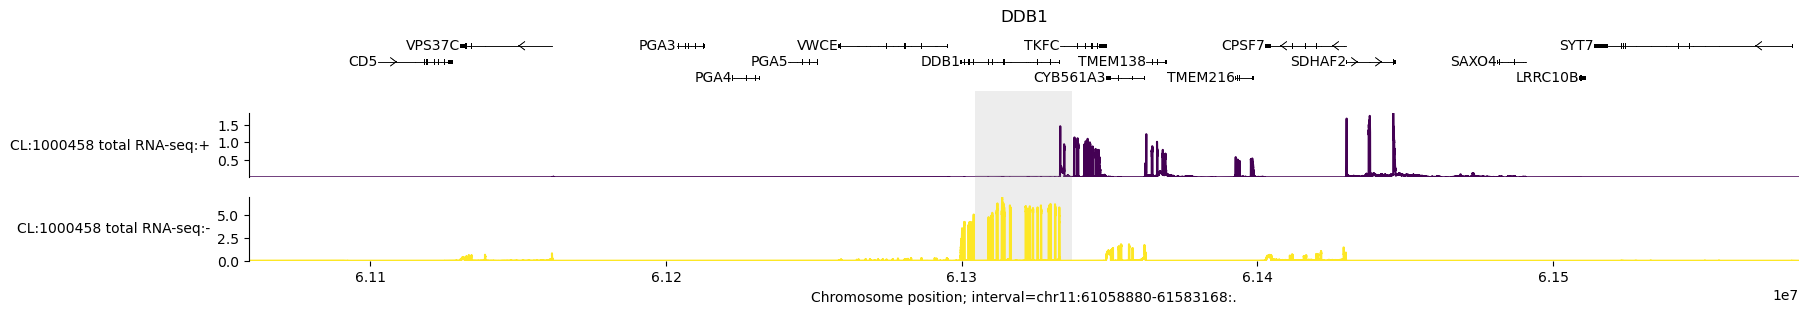

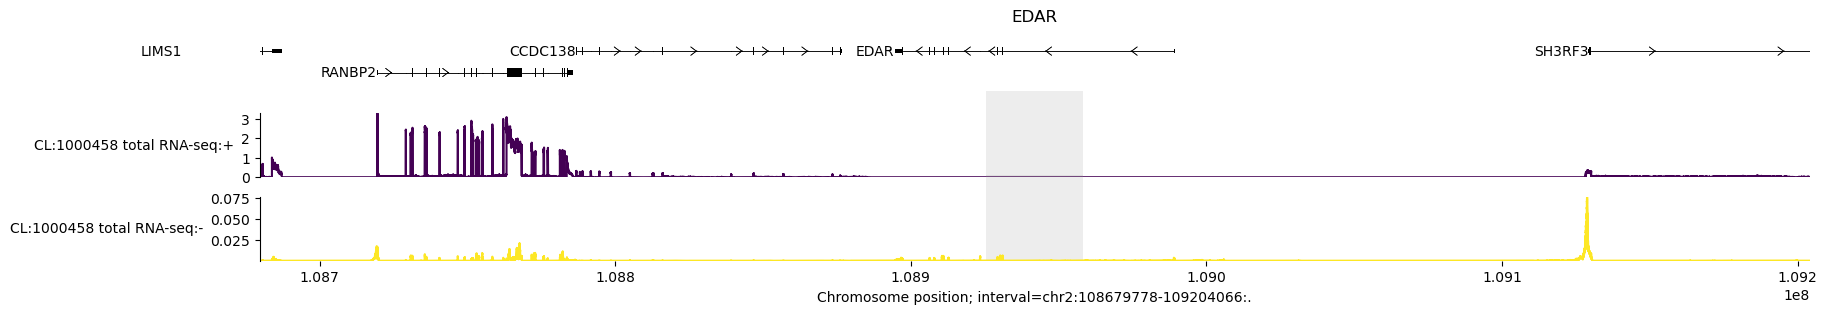

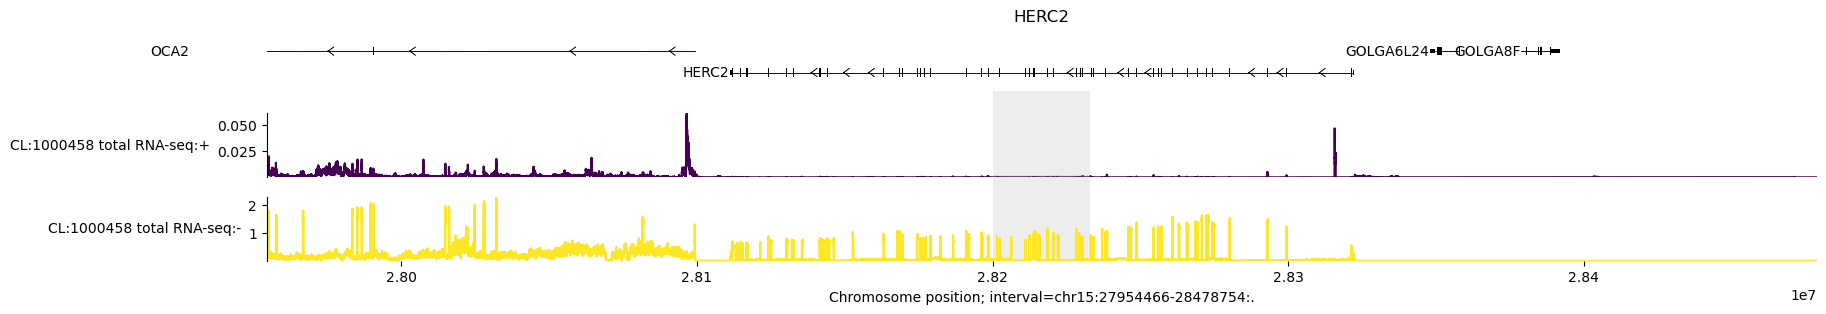

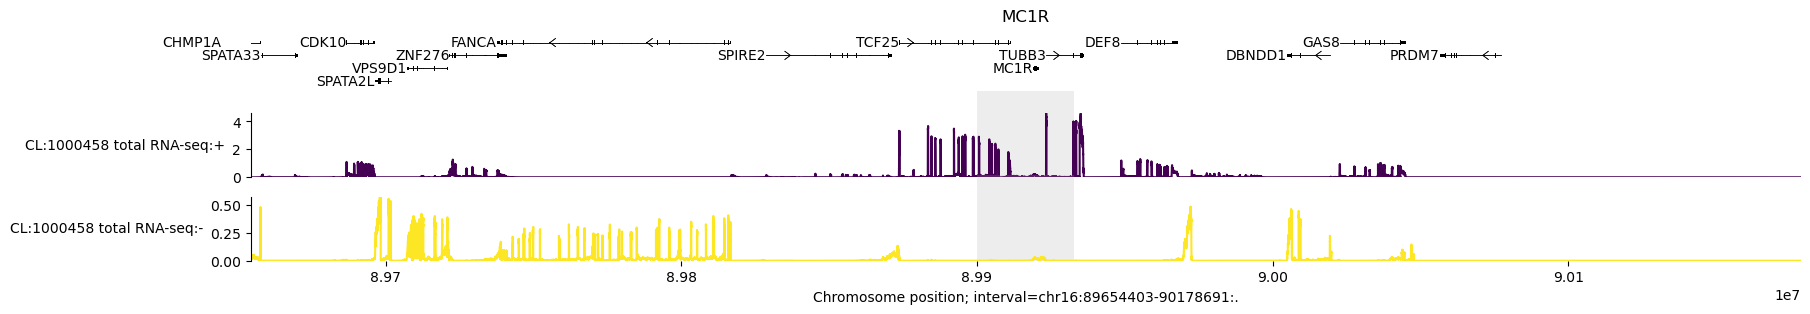

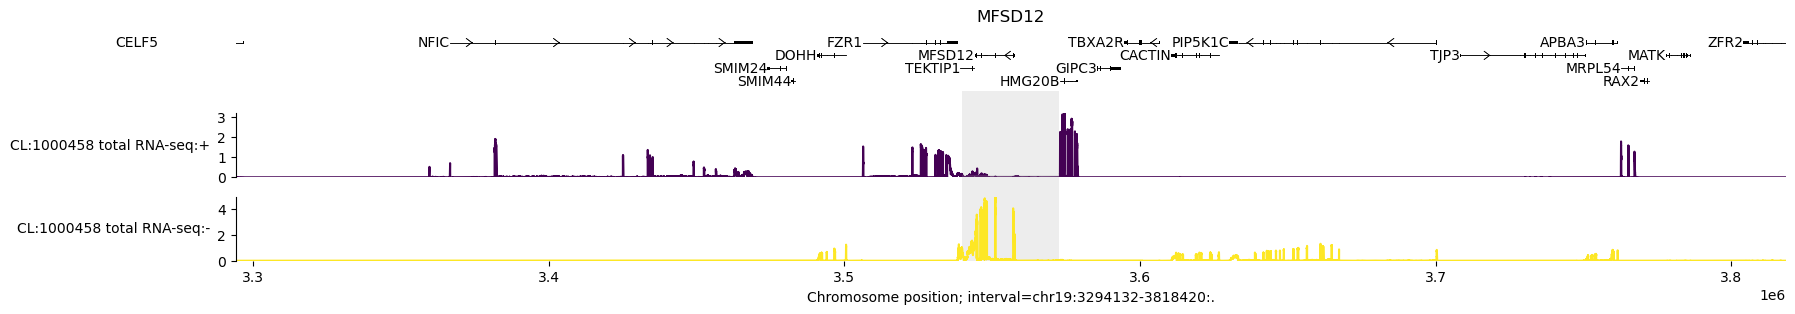

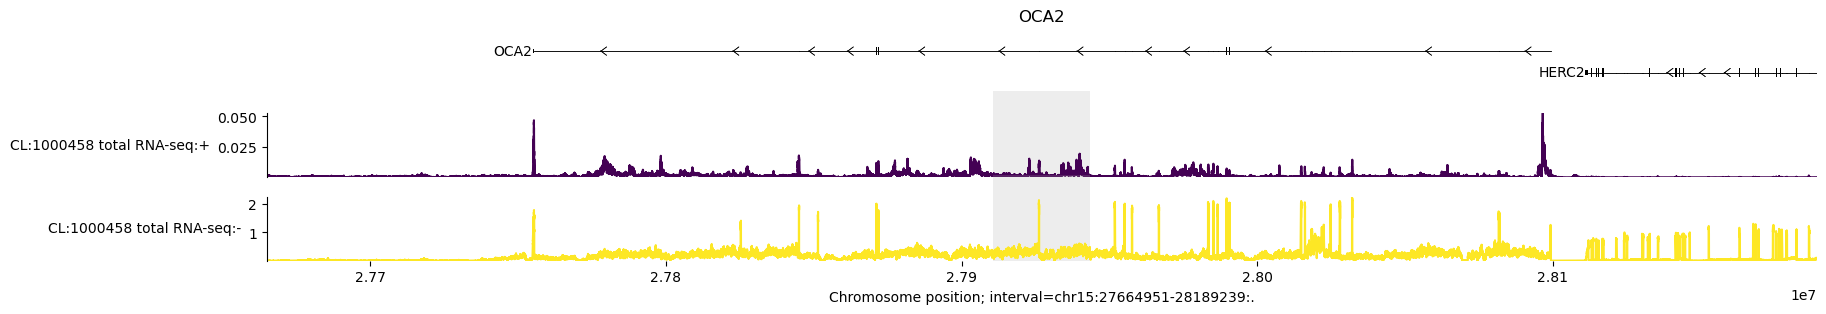

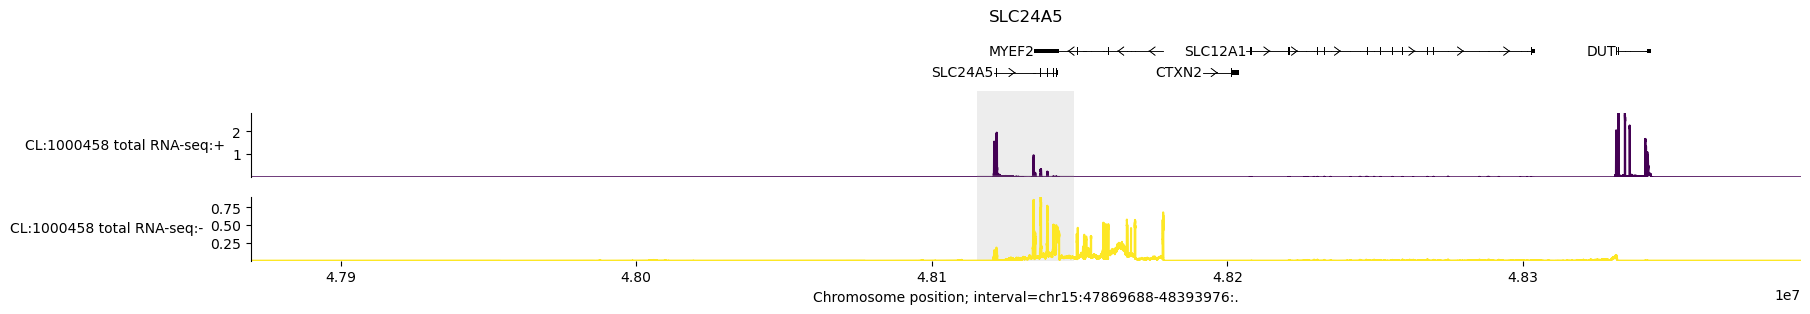

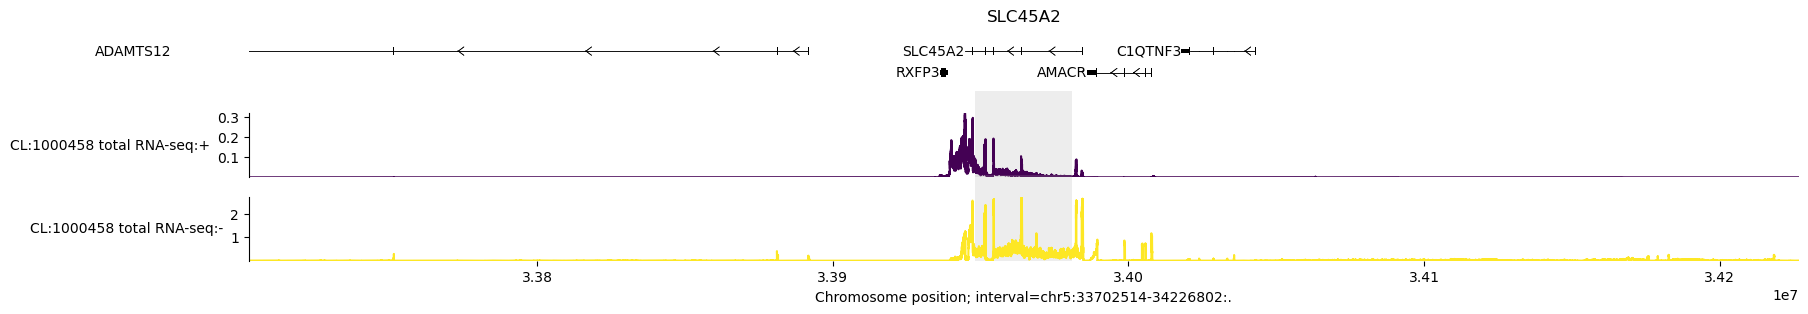

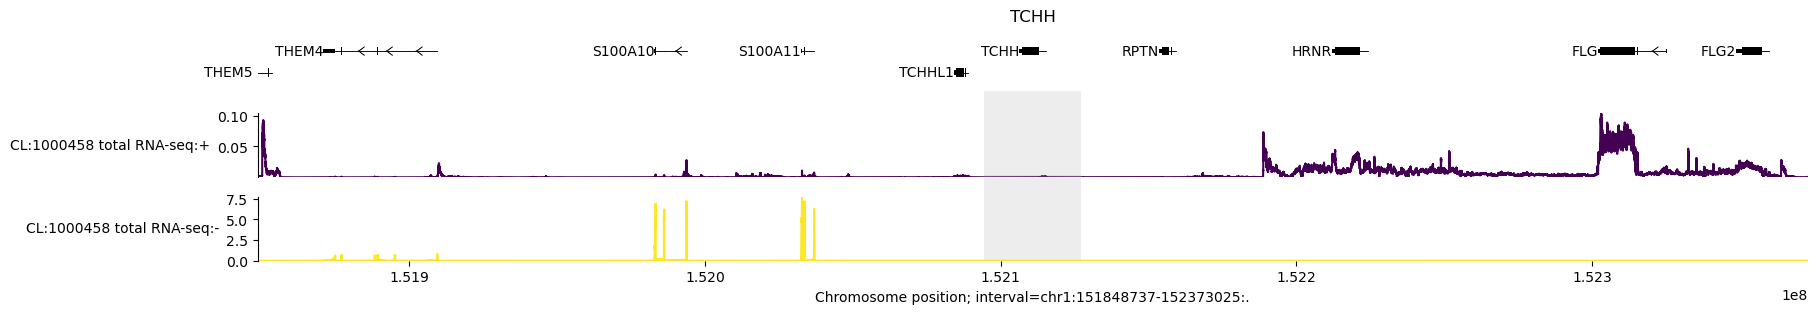

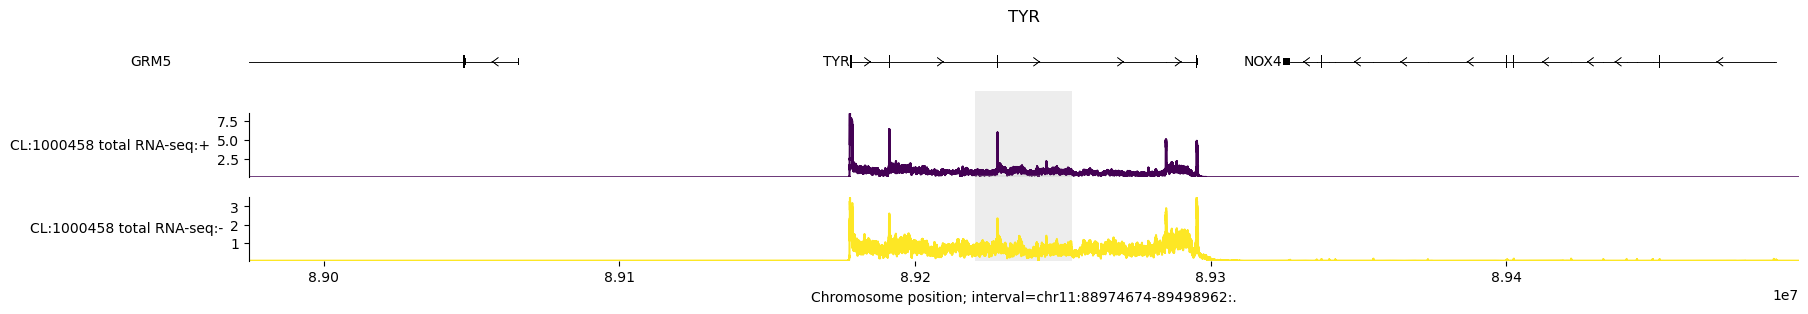

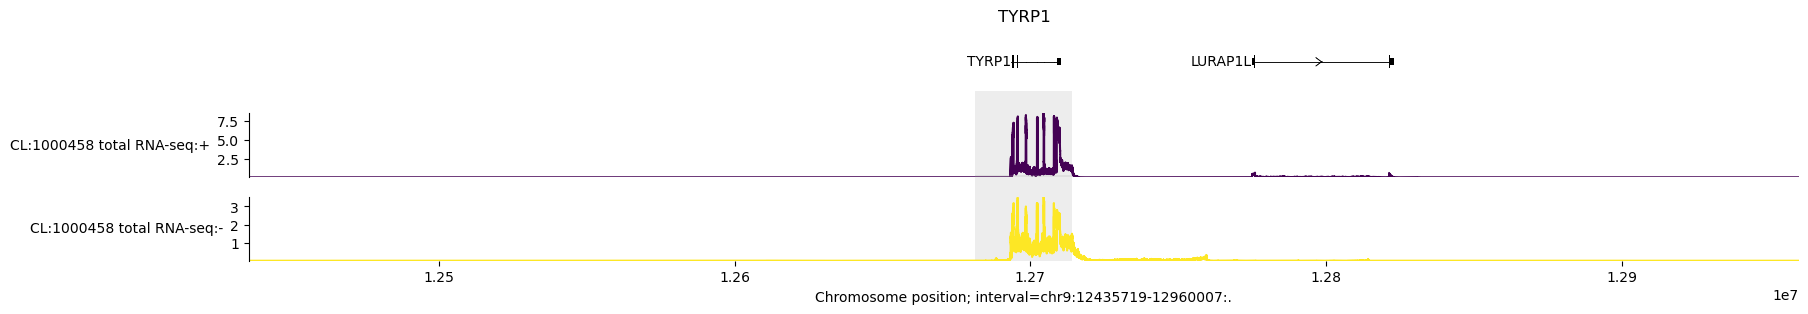

In [5]:
def plot_alphagenome_view_for_gene(
    gene: str,
    outer_window: int = dna_client.SEQUENCE_LENGTH_500KB,
    inner_window: int = 32768,
    filter_protein_coding = True,
    filter_mane_select_transcript = True,
):
    gene_data = windows_df.loc[windows_df["gene"] == gene].iloc[0]

    interval = genome.Interval(
        gene_data["chrom"],
        gene_data["start"],
        gene_data["end"],
    ).resize(outer_window)
    interval_32k = genome.Interval(
        gene_data["chrom"],
        gene_data["start"],
        gene_data["end"],
    ).resize(inner_window)

    gtf_transcripts = gtf
    if filter_protein_coding:
        gtf_transcripts = gene_annotation.filter_protein_coding(gtf)
    if filter_mane_select_transcript:
        gtf_transcripts = gene_annotation.filter_to_mane_select_transcript(gtf_transcripts)
    transcript_extractor = transcript_utils.TranscriptExtractor(gtf_transcripts)
    transcripts = transcript_extractor.extract(interval)

    output = client.predict_interval(
        interval=interval,
        requested_outputs=[dna_client.OutputType.RNA_SEQ],
        ontology_terms=[ONTOLOGY_TERMS[0]],
    )

    fig = plot_components.plot(
        components=[
            plot_components.TranscriptAnnotation(transcripts),
            plot_components.Tracks(output.rna_seq),
        ],
        annotations=[
            plot_components.IntervalAnnotation(
                intervals=[interval_32k]
            ),
        ],
        interval=interval,
        title=gene,
    )

    plt.show()      # Display this figure before creating the next one
    plt.close(fig)  # Optional: free memory

for gene in windows_df["gene"]:
    plot_alphagenome_view_for_gene(gene)

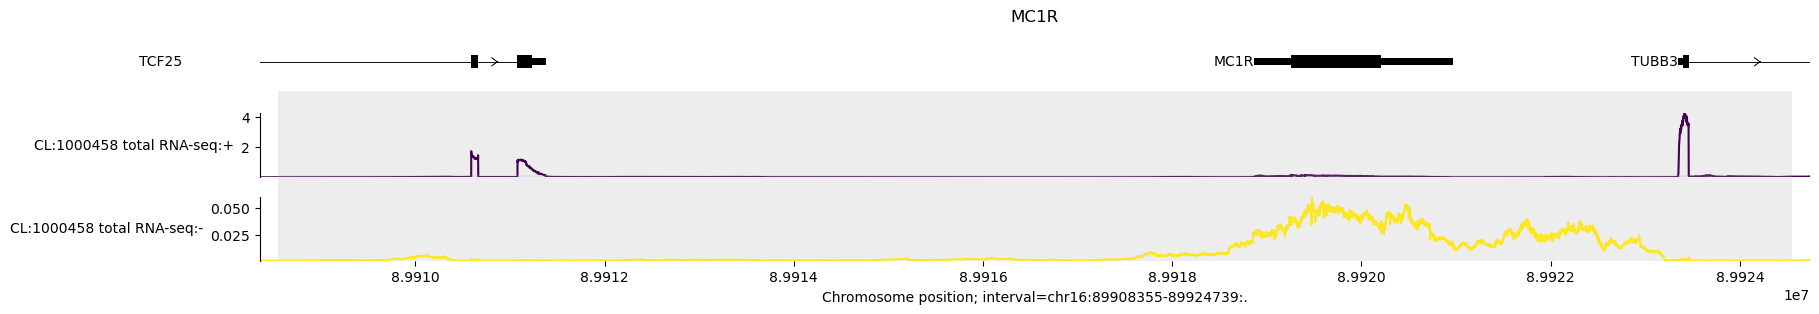

In [6]:
plot_alphagenome_view_for_gene("MC1R", dna_client.SEQUENCE_LENGTH_16KB, 16000)

## Individual genomes: strong vs. weak pigmentation, RNA-seq

Instead of predicting on the unmodified reference (as above), this builds each sample's own
diploid consensus sequence for a gene's window and runs *that* through AlphaGenome. The H1/H2
consensus FASTAs are built on the fly with `bcftools consensus`, against
`notebooks/data/variants/<gene>.vcf.gz` (a small, pre-sliced, sample-restricted VCF bundled with
this notebook -- see `notebooks/utils/prepare_data.py`) and `notebooks/data/references/<gene>/ref.window.fa`
as the reference. Results are cached under `notebooks/.cache/` so repeat runs for the same
sample/gene/haplotype are cheap -- see `notebooks/utils/consensus.py`.

One sample is picked per pigmentation class (from every individual in `notebooks/data/individuals.json`
whose population is in `CLASS_MAP`, not just the ones used to train the CNN) and its RNA-seq is
plotted the same way as the reference-only plot above (`predict_sequence` instead of
`predict_interval`, otherwise the same transcript annotation / inner-window box).

In [4]:
# Cache for on-the-fly-built individual consensus FASTAs (and their consensus-ready VCF
# subsets) -- kept next to the notebook, not under any external dataset path, since these
# are derived on demand from notebooks/data/variants/<gene>.vcf.gz.
CONSENSUS_CACHE_DIR = NOTEBOOK_DIR / ".cache" / "consensus"

CLASS_COLORS = {
    "strong pigmentation": "red",
    "weak pigmentation": "gray",
}


def pick_one_sample_per_class() -> dict:
    # Every individual in notebooks/data/individuals.json is available (all strong/weak
    # pigmentation individuals in this dataset, not just the ones used to train the CNN) --
    # deterministically pick the first (sorted) sample_id per class.
    return {
        class_name: {"sample_id": sample_ids[0], "population": individuals[sample_ids[0]]["population"]}
        for class_name, sample_ids in samples_by_class.items()
    }


def predict_individual_haplotype(sample_id: str, gene: str, haplotype: str, requested_outputs: list, ontology_terms: list):
    ref_window_fa, gene_vcf_path = data_utils.gene_paths(gene)
    return predictions_utils.predict_haplotype(
        client,
        gene=gene,
        gene_row=gene_rows[gene],
        sample_id=sample_id,
        haplotype=haplotype,
        requested_outputs=requested_outputs,
        ontology_terms=ontology_terms,
        ref_window_fa=ref_window_fa,
        gene_vcf_path=gene_vcf_path,
        consensus_cache_dir=CONSENSUS_CACHE_DIR,
    )

In [5]:
def plot_individual_rna_seq(sample_id: str, class_name: str, population: str, gene: str, ontologies: list):
    gene_data = windows_df.loc[windows_df["gene"] == gene].iloc[0]
    interval = genome.Interval(gene_data["chrom"], gene_data["start"], gene_data["end"])
    inner_interval = interval.resize(WINDOW_CENTER_SIZE)

    gtf_transcripts = gene_annotation.filter_to_mane_select_transcript(
        gene_annotation.filter_protein_coding(gtf)
    )
    transcripts = transcript_utils.TranscriptExtractor(gtf_transcripts).extract(interval)

    output_h1 = predict_individual_haplotype(sample_id, gene, "H1", [dna_client.OutputType.RNA_SEQ], ontologies)
    output_h2 = predict_individual_haplotype(sample_id, gene, "H2", [dna_client.OutputType.RNA_SEQ], ontologies)

    fig = plot_components.plot(
        components=[
            plot_components.TranscriptAnnotation(transcripts),
            plot_components.Tracks(output_h1.rna_seq, ylabel_template="H1 {name}:{strand}"),
            plot_components.Tracks(output_h2.rna_seq, ylabel_template="H2 {name}:{strand}"),
        ],
        annotations=[
            plot_components.IntervalAnnotation(intervals=[inner_interval]),
        ],
        interval=interval,
        title=f"{gene} -- {sample_id} ({population}, {class_name})",
    )
    plt.show()
    plt.close(fig)

def combined_rna_seq_track(sample_id: str, gene: str, ontologies: list):
    """Sum H1 + H2 RNA-seq tracks into one "total expression" track per individual."""
    output_h1 = predict_individual_haplotype(sample_id, gene, "H1", [dna_client.OutputType.RNA_SEQ], ontologies)
    output_h2 = predict_individual_haplotype(sample_id, gene, "H2", [dna_client.OutputType.RNA_SEQ], ontologies)
    return output_h1.rna_seq + output_h2.rna_seq

def plot_rna_seq_comparison(picked_samples: dict, gene: str, ontologies: list):
    gene_data = windows_df.loc[windows_df["gene"] == gene].iloc[0]
    gtf_transcripts_16k = gene_annotation.filter_to_mane_select_transcript(
        gene_annotation.filter_protein_coding(gtf)
    )
    strand = gtf_transcripts_16k.loc[
        (gtf_transcripts_16k["gene_name"] == gene) &
        (gtf_transcripts_16k["Feature"] == "transcript"),
        "Strand"
    ].iloc[0]

    # Zoom width is sized from the whole-gene GTF feature (spanning every transcript/isoform),
    # not just the MANE Select transcript's own span. `gene_data` (and therefore the center of
    # `plot_interval_gene` below) is already centered on this same "gene" feature at
    # dataset-build time -- sizing the zoom off the MANE transcript instead can visibly
    # off-center the plot when that one isoform's span sits asymmetrically within the full gene
    # body (observed for DDB1, MFSD12, TYRP1, MC1R).
    gene_span = gtf.loc[
        (gtf["Feature"] == "gene") & (gtf["gene_name"] == gene), ["Start", "End"]
    ].iloc[0]
    zoom_width = int((gene_span["End"] - gene_span["Start"]) * 1.5)

    plot_interval_gene = genome.Interval(
        gene_data["chrom"], gene_data["start"], gene_data["end"]
    ).resize(zoom_width)
    transcripts_16k = transcript_utils.TranscriptExtractor(gtf_transcripts_16k).extract(plot_interval_gene)

    if strand == '+':
        overlay_tracks = {
            class_name: combined_rna_seq_track(info["sample_id"], gene, ontologies)
            .filter_to_positive_strand()
            .slice_by_interval(plot_interval_gene)
            for class_name, info in picked_samples.items()
        }
    else:
            overlay_tracks = {
            class_name: combined_rna_seq_track(info["sample_id"], gene, ontologies)
            .filter_to_negative_strand()
            .slice_by_interval(plot_interval_gene)
            for class_name, info in picked_samples.items()
        }

    fig = plot_components.plot(
        components=[
            plot_components.TranscriptAnnotation(transcripts_16k),
            plot_components.OverlaidTracks(
                tdata=overlay_tracks,
                colors=CLASS_COLORS,
                ylabel_template="{name}",
            ),
        ],
        interval=plot_interval_gene,
        title=f"{gene} ({strand} strand) -- strong vs. weak pigmentation, H1+H2 summed",
    )
    ax = fig.axes[1]

    legend = ax.get_legend()
    if legend is not None:
        legend.set_loc("upper left")
    plt.show()
    plt.close(fig)

### MC1R 16 kb overlay: strong (red) vs. weak (gray), + strand only

Same two individuals as above, but both classes drawn on one shared axis (`OverlaidTracks`,
the pattern AlphaGenome's own REF/ALT comparison plots use) instead of separate figures, zoomed
to the 16 kb window around MC1R and restricted to the `+` strand -- the strand MC1R itself is
transcribed on, so the `-` strand tracks are just the neighboring antisense signal and would
otherwise clutter the comparison. H1 and H2 are summed per individual first (independent-haplotype
assumption, the same `haplotype_mode="sum"` used by the scalar gene-expression classifier)
so each class contributes exactly one track to the overlay.

In [ ]:
GENE_FOR_COMPARISON = "DDB1"
ONTOLOGY_TERM_FOR_COMPARISON = ONTOLOGY_TERMS[0]

picked_samples = pick_one_sample_per_class()
for class_name, info in picked_samples.items():
    print(f"{class_name}: {info['sample_id']} ({info['population']})")

# for class_name, info in picked_samples.items():
#     plot_individual_rna_seq(info["sample_id"], class_name, info["population"], GENE_FOR_COMPARISON, [ONTOLOGY_TERM_FOR_COMPARISON])

# plot_rna_seq_comparison(picked_samples, GENE_FOR_COMPARISON, [ONTOLOGY_TERM_FOR_COMPARISON])

for gene in GENES:
    plot_rna_seq_comparison(picked_samples, gene, [ONTOLOGY_TERM_FOR_COMPARISON])

## Generating predictions for every strong/weak pigmentation individual

The two comparisons above use one hand-picked individual per class. `notebooks/utils/predictions.py`
generalizes this to *every* individual in `notebooks/data/individuals.json` (1,072 people across the
8 populations in `CLASS_MAP`): for each (gene, sample, haplotype) it builds the consensus FASTA,
predicts, realigns, and caches the result to `notebooks/.cache/predictions/<gene>/<sample>.<haplotype>.npz`.

This is expensive at full scope -- 11 genes x 1,072 individuals x 2 haplotypes is ~23,600 AlphaGenome
API calls. `generate_predictions()` is resumable (skips anything already cached on disk), so it's safe
to widen `genes=`/`sample_ids=` incrementally over multiple runs rather than committing to the full
scope up front. The cell below runs a small demo (one gene, a handful of individuals per class) so you
can see it working before deciding how far to scale it.

In [6]:
PREDICTIONS_CACHE_DIR = NOTEBOOK_DIR / ".cache" / "predictions"

# Demo scope: 1 gene x 5 individuals per class x 2 haplotypes = 20 AlphaGenome calls.
# Widen DEMO_GENES / DEMO_N_PER_CLASS (or pass sample_ids=list(individuals) for every
# individual) to scale up -- already-generated (gene, sample, haplotype) results are
# skipped automatically.
DEMO_GENES = ["DDB1"]
DEMO_N_PER_CLASS = 5
demo_sample_ids = [
    sample_id
    for class_name, sample_ids in samples_by_class.items()
    for sample_id in sample_ids[:DEMO_N_PER_CLASS]
]
print(f"Demo scope: {len(DEMO_GENES)} gene(s) x {len(demo_sample_ids)} individuals x 2 haplotypes "
      f"= {len(DEMO_GENES) * len(demo_sample_ids) * 2} predictions")

def _on_progress(done, total, gene, sample_id, haplotype, status):
    print(f"[{done}/{total}] {gene} {sample_id} {haplotype}: {status}")

demo_results = predictions_utils.generate_predictions(
    client,
    genes=DEMO_GENES,
    gene_rows=gene_rows,
    gene_paths_fn=data_utils.gene_paths,
    sample_ids=demo_sample_ids,
    ontology_terms=[ONTOLOGY_TERM_FOR_COMPARISON],
    output_dir=PREDICTIONS_CACHE_DIR,
    consensus_cache_dir=CONSENSUS_CACHE_DIR,
    on_progress=_on_progress,
)
pd.DataFrame(demo_results)[["gene", "sample_id", "haplotype", "status"]]

Demo scope: 1 gene(s) x 10 individuals x 2 haplotypes = 20 predictions


[1/20] DDB1 HG02461 H1: generated


[2/20] DDB1 HG02461 H2: generated


[3/20] DDB1 HG02462 H1: generated


[4/20] DDB1 HG02462 H2: generated


...

[17/20] DDB1 HG00100 H1: generated


[18/20] DDB1 HG00100 H2: generated


[19/20] DDB1 HG00101 H1: generated


[20/20] DDB1 HG00101 H2: generated


,gene,sample_id,haplotype,status
0,DDB1,HG02461,H1,generated
1,DDB1,HG02461,H2,generated
2,DDB1,HG02462,H1,generated
3,DDB1,HG02462,H2,generated
4,DDB1,HG02463,H1,generated
5,DDB1,HG02463,H2,generated
6,DDB1,HG02464,H1,generated
7,DDB1,HG02464,H2,generated
8,DDB1,HG02465,H1,generated
9,DDB1,HG02465,H2,generated


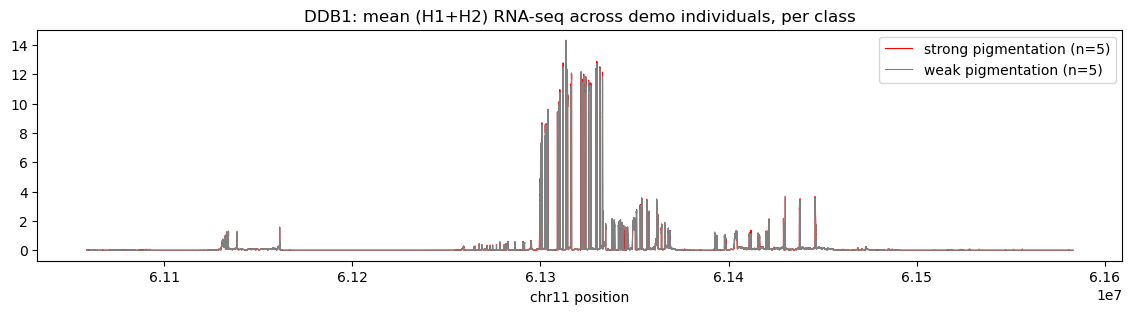

In [7]:
def load_combined_rna_seq(gene: str, sample_id: str):
    """Loads a cached (H1 + H2) summed RNA-seq track for one individual, generated above."""
    h1_npz, h1_meta = PREDICTIONS_CACHE_DIR / gene / f"{sample_id}.H1.npz", PREDICTIONS_CACHE_DIR / gene / f"{sample_id}.H1.json"
    h2_npz, h2_meta = PREDICTIONS_CACHE_DIR / gene / f"{sample_id}.H2.npz", PREDICTIONS_CACHE_DIR / gene / f"{sample_id}.H2.json"
    h1 = predictions_utils.load_rna_seq(h1_npz, h1_meta)
    h2 = predictions_utils.load_rna_seq(h2_npz, h2_meta)
    return h1 + h2


def mean_track_by_class(gene: str, sample_ids_by_class: dict):
    """Averages the (H1+H2) track across every demo individual in each class."""
    return {
        class_name: np.mean(
            [load_combined_rna_seq(gene, sample_id).values for sample_id in sample_ids],
            axis=0,
        )
        for class_name, sample_ids in sample_ids_by_class.items()
    }


demo_gene = DEMO_GENES[0]
demo_sample_ids_by_class = {
    class_name: [s for s in sample_ids[:DEMO_N_PER_CLASS]]
    for class_name, sample_ids in samples_by_class.items()
}
mean_tracks = mean_track_by_class(demo_gene, demo_sample_ids_by_class)

gene_data = windows_df.loc[windows_df["gene"] == demo_gene].iloc[0]
positions = np.arange(gene_data["start"], gene_data["end"])

fig, ax = plt.subplots(figsize=(14, 3))
for class_name, track in mean_tracks.items():
    ax.plot(positions, track.sum(axis=1), label=f"{class_name} (n={len(demo_sample_ids_by_class[class_name])})",
            color=CLASS_COLORS[class_name], linewidth=0.8)
ax.set_title(f"{demo_gene}: mean (H1+H2) RNA-seq across demo individuals, per class")
ax.set_xlabel(f"{gene_data['chrom']} position")
ax.legend()
plt.show()
plt.close(fig)